# Name: Muhammad Choudhary
# Student Number: 991630737
# Artificial Intelligence Research Assignment

##### Since my student number ends with 7. I will be working with project number 7, the Wine Quality Data Set. The task will be regression and the target value is alcohol.

##### Different regression models will be created using PyCaret. 

In [154]:
# Get the winequality-red dataset 
! curl -O https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84199    0 84199    0     0    99k      0 --:--:-- --:--:-- --:--:--   99k


In [155]:
# Then load the dataset
import pandas as pd
df_wine = pd.read_csv('winequality-red.csv', sep=';')

In [156]:
# View the data
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


The different features in the red wine dataset are: 
- fixed acidity
- volatile acidity 
- citric acid 
- residual sugar
- chlorides 
- free sulfur dioxide 
- total sulfur dioxide 
- density
- pH 
- sulphates
- quality

The target value is alcohol

In [157]:
# Install the full version of pycaret
! pip install "pycaret[full]"

  Obtaining dependency information for kmodes>=0.11.1 from https://files.pythonhosted.org/packages/1a/a8/0d3bf6f3340cbcb8cf4ad02c306d157af8f09ce86aadf5346e00605870dd/kmodes-0.12.2-py2.py3-none-any.whl.metadata
  Using cached kmodes-0.12.2-py2.py3-none-any.whl.metadata (8.1 kB)
  Obtaining dependency information for mlxtend>=0.19.0 from https://files.pythonhosted.org/packages/4c/43/2fc7f76c8891aef148901f1ba3dee65c1cbac00a85ae5ee0dabc2b861256/mlxtend-0.23.4-py3-none-any.whl.metadata
  Using cached mlxtend-0.23.4-py3-none-any.whl.metadata (7.3 kB)
  Obtaining dependency information for statsforecast<1.6.0,>=0.5.5 from https://files.pythonhosted.org/packages/ff/a1/7140ebf2bb1c513275d13a63b4718f531f5e0f285bb92e0d954009ad41ef/statsforecast-1.5.0-py3-none-any.whl.metadata
  Using cached statsforecast-1.5.0-py3-none-any.whl.metadata (23 kB)
  Obtaining dependency information for hyperopt>=0.2.7 from https://files.pythonhosted.org/packages/b6/cd/5b3334d39276067f54618ce0d0b48ed69d91352fbf137468c

In [158]:
# Check the python version
! python --version

Python 3.11.7


In [159]:
# Check the installed version
import pycaret
pycaret.__version__

'3.3.2'

In [160]:
# First setup the training environment
# Import regression
from pycaret.regression import *

# Use the setup function to initialize the experiment and create the transformation pipeline
s = setup(df_wine, target = 'alcohol', session_id = 123)

,Description,Value
0,Session id,123
1,Target,alcohol
2,Target type,Regression
3,Original data shape,"(1599, 12)"
4,Transformed data shape,"(1599, 12)"
5,Transformed train set shape,"(1119, 12)"
6,Transformed test set shape,"(480, 12)"
7,Numeric features,11
8,Preprocess,True
9,Imputation type,simple


#### From the above table:
#### target type is regression and the target is alcohol
#### The original data shape is (1599, 12)
#### The transformed train shape is (1119, 12)
#### The transformed test shape is (480, 12)
#### The numeric features are 11
#### There are no categorical features

## Comparing the Best Models according to MAE and R2

In [161]:
# Now compare the models
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.3502,0.2694,0.5169,0.7527,0.0440,0.0333,0.3000
et,Extra Trees Regressor,0.3445,0.2801,0.5276,0.7440,0.0450,0.0327,0.0360
rf,Random Forest Regressor,0.3759,0.2946,0.5408,0.7301,0.0462,0.0358,0.0630
gbr,Gradient Boosting Regressor,0.3995,0.2965,0.5430,0.7294,0.0464,0.0381,0.0320
lar,Least Angle Regression,0.4532,0.3609,0.5971,0.6692,0.0517,0.0434,0.0040
lr,Linear Regression,0.4532,0.3609,0.5971,0.6691,0.0517,0.0434,0.3410
ada,AdaBoost Regressor,0.5605,0.4679,0.6825,0.5726,0.0591,0.0543,0.0180
dt,Decision Tree Regressor,0.4763,0.5556,0.7433,0.4873,0.0635,0.0450,0.0050
br,Bayesian Ridge,0.6658,0.7470,0.8613,0.3200,0.0733,0.0630,0.0040
ridge,Ridge Regression,0.6673,0.7503,0.8632,0.3169,0.0734,0.0632,0.0040


In [162]:
# Check all the available models for regression
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [164]:
# Now find the top 3 models based on MAE
best_mae_models_top3 = compare_models(sort = 'MAE', n_select = 3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3445,0.2801,0.5276,0.7440,0.0450,0.0327,0.0360
lightgbm,Light Gradient Boosting Machine,0.3502,0.2694,0.5169,0.7527,0.0440,0.0333,0.3250
rf,Random Forest Regressor,0.3759,0.2946,0.5408,0.7301,0.0462,0.0358,0.0630
gbr,Gradient Boosting Regressor,0.3995,0.2965,0.5430,0.7294,0.0464,0.0381,0.0300
lr,Linear Regression,0.4532,0.3609,0.5971,0.6691,0.0517,0.0434,0.0040
lar,Least Angle Regression,0.4532,0.3609,0.5971,0.6692,0.0517,0.0434,0.0040
dt,Decision Tree Regressor,0.4763,0.5556,0.7433,0.4873,0.0635,0.0450,0.0060
ada,AdaBoost Regressor,0.5605,0.4679,0.6825,0.5726,0.0591,0.0543,0.0170
br,Bayesian Ridge,0.6658,0.7470,0.8613,0.3200,0.0733,0.0630,0.0040
ridge,Ridge Regression,0.6673,0.7503,0.8632,0.3169,0.0734,0.0632,0.0040


In [165]:
best_mae_models_top3

[ExtraTreesRegressor(n_jobs=-1, random_state=123),
 LGBMRegressor(n_jobs=-1, random_state=123),
 RandomForestRegressor(n_jobs=-1, random_state=123)]

#### The best model based on MAE:
##### When comparing models based on MAE. The Extra Trees Regressor is the best and has the lowest Mean Absolute Error of 0.3445 in the top 3. This means the average absolute difference between the predicted values and the actual values are 0.3445.

---

In [166]:
# The compare_models has other parameters that can be used to different comparisons
# By default the fold = 10 and cross-validation is true, so no need to speicify
# With fold = 10, the data will be split into 10 equal parts.
# The model will train on 9 parts and test on 1 part
# Having 10 folds will give a good balance of variety and bias when comparing the models


# It will be soritng by R2
# R2 is the coefficent of determination
# It measures how much of the variance in the target variable is explained by the model
# With n_select = 3, get the top 3
best_model_r2 = compare_models(
    n_select = 3,
    sort='R2'
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.3502,0.2694,0.5169,0.7527,0.0440,0.0333,0.3480
et,Extra Trees Regressor,0.3445,0.2801,0.5276,0.7440,0.0450,0.0327,0.0370
rf,Random Forest Regressor,0.3759,0.2946,0.5408,0.7301,0.0462,0.0358,0.0730
gbr,Gradient Boosting Regressor,0.3995,0.2965,0.5430,0.7294,0.0464,0.0381,0.0360
lar,Least Angle Regression,0.4532,0.3609,0.5971,0.6692,0.0517,0.0434,0.0040
lr,Linear Regression,0.4532,0.3609,0.5971,0.6691,0.0517,0.0434,0.0060
ada,AdaBoost Regressor,0.5605,0.4679,0.6825,0.5726,0.0591,0.0543,0.0190
dt,Decision Tree Regressor,0.4763,0.5556,0.7433,0.4873,0.0635,0.0450,0.0050
br,Bayesian Ridge,0.6658,0.7470,0.8613,0.3200,0.0733,0.0630,0.0030
ridge,Ridge Regression,0.6673,0.7503,0.8632,0.3169,0.0734,0.0632,0.0040


In [167]:
# Display the top 3 results
best_model_r2

[LGBMRegressor(n_jobs=-1, random_state=123),
 ExtraTreesRegressor(n_jobs=-1, random_state=123),
 RandomForestRegressor(n_jobs=-1, random_state=123)]

#### The best model based on R2:
##### When sorted based on R2 and compared with 10 folds cross validation. The best performing model is now Light Gradient Boosting Machine with a R2 of 0.7833. This means that 78.33% of the variance in alcohol is explained by the features in the data set.

---

## Tuning and comparing different models

##### The best model so far based on R2 is Light Gradient Boosting Machine (lgbm). Now comparing baseline lgbm with tuned lgbm. First create regular lgbm model and store R2, MAE and RMSE results.

In [168]:
# Create the model
lgbm_model = create_model('lightgbm')
lgbm_results = pull()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3274,0.1962,0.4430,0.7728,0.0397,0.0324
1,0.4045,0.3598,0.5999,0.6505,0.0514,0.0384
2,0.3589,0.2715,0.5210,0.7726,0.0447,0.0342
3,0.3786,0.2829,0.5319,0.7848,0.0456,0.0361
4,0.2813,0.1942,0.4407,0.7816,0.0373,0.0266
5,0.3400,0.2531,0.5031,0.7886,0.0417,0.0314
6,0.3364,0.3284,0.5731,0.7029,0.0462,0.0310
7,0.3529,0.2465,0.4964,0.8012,0.0431,0.0339
8,0.3553,0.2869,0.5357,0.6843,0.0460,0.0339


In [169]:
# Now store the result
# Store baseline results
regular_r2 = lgbm_results['R2'].mean()
regular_rmse = lgbm_results['RMSE'].mean()
regular_mae = lgbm_results['MAE'].mean()

#### Now create and store the tuned lgbm model
#### Optimize by R2

In [170]:
# Tune the model
tuned_lgbm_model = tune_model(lgbm_model, optimize='R2')
tuned_results = pull()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3454,0.1871,0.4325,0.7833,0.0385,0.0340
1,0.4766,0.4354,0.6598,0.5771,0.0566,0.0451
2,0.4216,0.3386,0.5819,0.7163,0.0503,0.0406
3,0.4400,0.3776,0.6145,0.7128,0.0521,0.0418
4,0.3504,0.2412,0.4911,0.7288,0.0415,0.0329
5,0.4358,0.4030,0.6348,0.6634,0.0530,0.0401
6,0.3708,0.3271,0.5719,0.7041,0.0475,0.0347
7,0.3892,0.2571,0.5071,0.7926,0.0441,0.0372
8,0.4429,0.3319,0.5761,0.6348,0.0498,0.0426


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [171]:
# Store the results
tuned_r2 = tuned_results['R2'].mean()
tuned_rmse = tuned_results['RMSE'].mean()
tuned_mae = tuned_results['MAE'].mean()

#### Compare the results

In [172]:
print(f"Comparing Regular (Non-tuned) with Tuned LGBM model:")

print(f"Regular R2: {regular_r2:.3f}")
print(f"Tuned  R2: {tuned_r2:.3f}")


print(f"Regular RMSE: {regular_rmse:.3f}")
print(f"Tuned  RMSE: {tuned_rmse:.3f}")


print(f"Regular MAE: {regular_mae:.3f}")
print(f"Tuned  MAE: {tuned_mae:.3f}")

Comparing Regular (Non-tuned) with Tuned LGBM model:
Regular R2: 0.694
Tuned  R2: 0.651
Regular RMSE: 0.478
Tuned  RMSE: 0.524
Regular MAE: 0.324
Tuned  MAE: 0.377


## Tuned compared to Non-tuned:
#### When comparing tuned lgbm model with non-tuned lgbm model. The non-tuned regular lgbm model is better because it has a higher R2 and lower MAE compared to the tuned model. This means that the tuned model could be overfitting. The tuned model is finding hyperparameters that fit the training data too good. Then the tuned model can't do well on the test data. Also, the regular lgbm model already has really good parameters and does not to be tuned. Also, maybe the tuning model could be needing more data to find better parameters. 

## Ensemble, Blend and Stacked Models
#### Create bagged, blend and stacked model

#### For the stack and blend models, a new model will be created with the top 3 models based on R2. They are Light Gradient Boosting Machine, Extra Trees Regressor and Random Forest Regressor

In [173]:
# Create a model with bagging
lgbm_bagged = ensemble_model(lgbm_model, method="Bagging")
bagged_results = pull()

# Blend the the top 3 models
blend_models_r2 = blend_models(best_model_r2)
blend_r2_results = pull()

# Stack model
stack_models_r2 = stack_models(best_model_r2)
stack_r2_results = pull()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3321,0.1866,0.4320,0.7839,0.0386,0.0327
1,0.4112,0.3458,0.5881,0.6641,0.0505,0.0390
2,0.3442,0.2373,0.4871,0.8012,0.0421,0.0330
3,0.3762,0.2660,0.5157,0.7977,0.0441,0.0359
4,0.2902,0.2199,0.4690,0.7527,0.0396,0.0274
5,0.3437,0.2570,0.5070,0.7853,0.0417,0.0316
6,0.3337,0.3224,0.5678,0.7083,0.0457,0.0308
7,0.3687,0.2494,0.4994,0.7988,0.0433,0.0352
8,0.3529,0.2651,0.5149,0.7083,0.0443,0.0338


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3071,0.1813,0.4258,0.7901,0.0382,0.0305
1,0.3987,0.3427,0.5854,0.6671,0.0506,0.0380
2,0.3532,0.2535,0.5035,0.7877,0.0435,0.0339
3,0.3530,0.2548,0.5048,0.8062,0.0432,0.0337
4,0.2696,0.2094,0.4576,0.7646,0.0387,0.0254
5,0.3378,0.2585,0.5084,0.7841,0.0415,0.0308
6,0.3150,0.2955,0.5436,0.7327,0.0437,0.0290
7,0.3766,0.2734,0.5229,0.7795,0.0452,0.0360
8,0.3365,0.2666,0.5163,0.7066,0.0443,0.0321


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3008,0.1782,0.4222,0.7936,0.0377,0.0296
1,0.3945,0.3392,0.5824,0.6706,0.0501,0.0375
2,0.3422,0.2446,0.4946,0.7951,0.0426,0.0328
3,0.3450,0.2570,0.5069,0.8045,0.0435,0.0329
4,0.2768,0.1973,0.4442,0.7782,0.0375,0.0261
5,0.3253,0.2416,0.4916,0.7982,0.0404,0.0299
6,0.3108,0.3051,0.5524,0.7240,0.0444,0.0286
7,0.3453,0.2451,0.4951,0.8023,0.0431,0.0332
8,0.3307,0.2640,0.5139,0.7095,0.0442,0.0315


#### Comparing the blended, stacked and bagged models

In [174]:
# Store results for bagged
bagged_r2 = bagged_results['R2'].mean()
bagged_rmse = bagged_results['RMSE'].mean()
bagged_mae = bagged_results['MAE'].mean()


# Store the results for blended
blended_r2 = blend_r2_results['R2'].mean()
blended_rmse = blend_r2_results['RMSE'].mean()
blended_mae = blend_r2_results['MAE'].mean()

# Store the results for stacked
stacked_r2 = stack_r2_results['R2'].mean()
stacked_rmse = stack_r2_results['RMSE'].mean()
stacked_mae = stack_r2_results['MAE'].mean()

In [175]:

print(f"Comparing Bagged, Blended, Stacked and Regular (Non-tuned):")

print(f"Bagged R2: {bagged_r2:.3f}")
print(f"Blended R2: {blended_r2:.3f}")
print(f"Stacked R2: {stacked_r2:.3f}")
print(f"Regular R2: {regular_r2:.3f}")


print("--" * 50)

print(f"Bagged RMSE: {bagged_rmse:.3f}")
print(f"Blended RMSE: {blended_rmse:.3f}")
print(f"Stacked RMSE: {stacked_rmse:.3f}")
print(f"Regular RMSE: {regular_rmse:.3f}")


print("--" * 50)


print(f"Bagged MAE: {bagged_mae:.3f}")
print(f"Blended MAE: {blended_mae:.3f}")
print(f"Stacked MAE: {stacked_mae:.3f}")
print(f"Regular MAE: {regular_mae:.3f}")

Comparing Bagged, Blended, Stacked and Regular (Non-tuned):
Bagged R2: 0.700
Blended R2: 0.700
Stacked R2: 0.707
Regular R2: 0.694
----------------------------------------------------------------------------------------------------
Bagged RMSE: 0.471
Blended RMSE: 0.472
Stacked RMSE: 0.464
Regular RMSE: 0.478
----------------------------------------------------------------------------------------------------
Bagged MAE: 0.326
Blended MAE: 0.318
Stacked MAE: 0.308
Regular MAE: 0.324


## Result comparing bagged, blended and stacked:
#### The R2, RMSE, MAE are very similar for all the models. But the stacked model has the higest R2 of 0.726. Also, the stacked model has a lower RMSE of 0.726 and lower MAE of 0.310. This means that the stacked model is slightly out performing all the other models. 

## Analyze Model

#### Use plot_mode to analyze the lgbm model

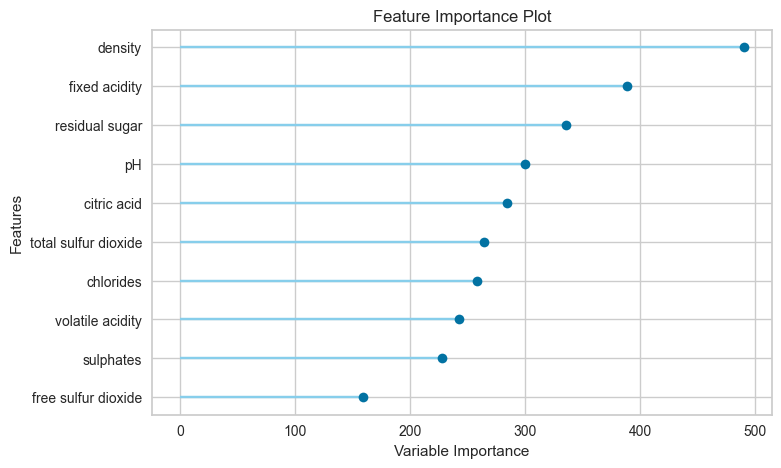

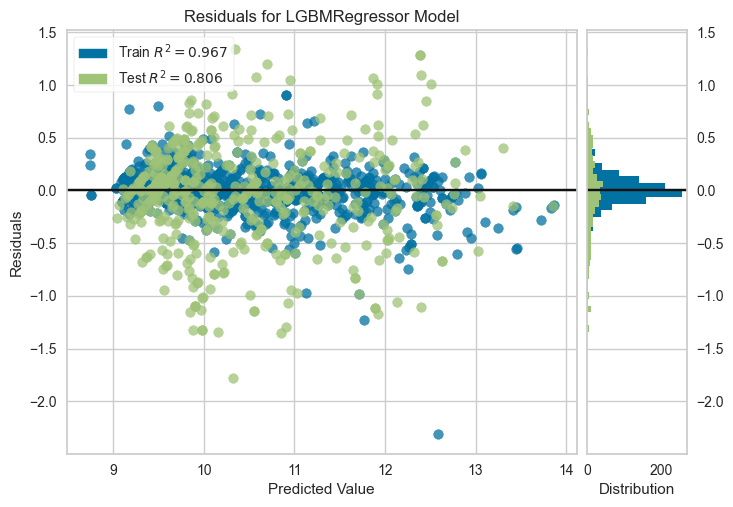

In [176]:
# This will plot the most important features
plot_model(lgbm_model, plot='feature')


# This will plot the residuals 
plot_model(lgbm_model, plot = 'residuals')

#### The feature importance plot will show how important features are by a score. It shows which features are the most usefull in making the prediction. It shows that the density, fixed acidity and PH are the most important features when making predictions. 

#### The residual plot will show the difference between the actual value and the predicted one. The plot shows that the train data is very close to the zero. While the testing data is a bit further from the zero. It also shows a wider spread for the testing data compared to the training data. This means this model is a bit over fitted. It performs better on training data, rather than testing data. 

# Interpret Model
#### These plots are implemented based on SHAP (Shapley Additive exPlanations)

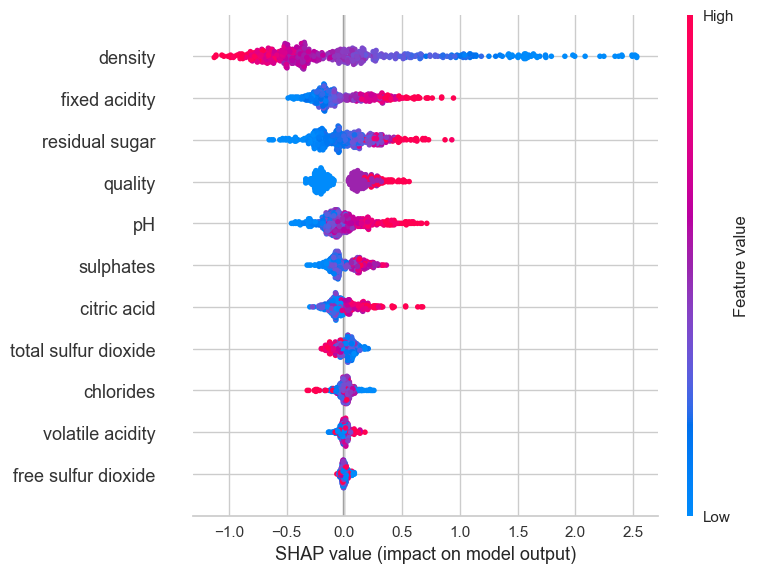

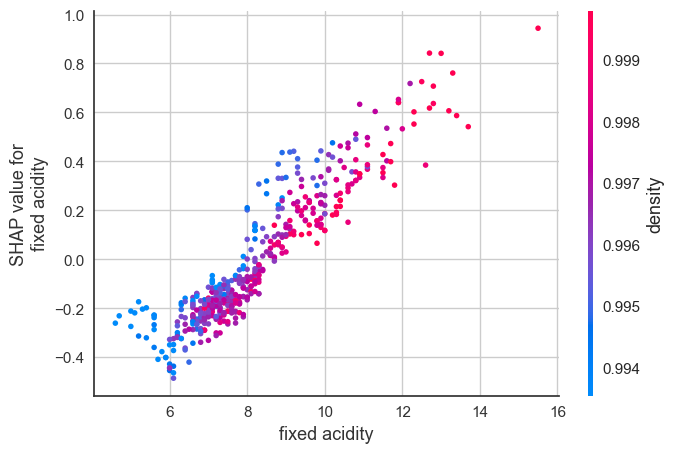

In [183]:
# The intrepret_model will analyze predictions generated from the LGBM model
interpret_model(lgbm_model)

# Plot will show the correlation between feature value and SHAP value
interpret_model(lgbm_model, plot='correlation')

#### The intrepret_model shows that the top features push away a prediction from what the average prediction is. The three most important features are density, residual sugar, and fixed acidity. The Pink or Red dots are on the left, that means that the higher density will decrease the alcohol prediction. But the Blue Dots (low density) will increase the alcohol prediction. The residual sugar is slightly pink to the right, this means that sugar has a small increase in alcohol prediction. The third is fixed acidity, it has blue dots on the left and red or pink dots on the right. This means that low fixed acidity decreases alcohol prediction and high density increases it.

#### The correlation plot shows a strong trend from left corner to right corner. This means that model will predict a higher alcohol content as the fixed acidity increases. 

# Making Predictions

#### Using the stack_models_r2 to make predictions on the holdout set and new data after droping the alcohol column

In [ ]:
# Predicting on the holdout set
predictions_holdout = predict_model(stack_models_r2)
predictions_holdout.head(10)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Stacking Regressor,0.3426,0.2311,0.4807,0.8040,0.0411,0.0322


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,alcohol,prediction_label
912,10.0,0.460,0.44,2.9,0.065,4.0,8.0,0.99674,3.33,0.62,6,12.2,10.963560
772,9.5,0.570,0.27,2.3,0.082,23.0,144.0,0.99782,3.27,0.55,5,9.4,9.429229
1037,7.3,0.910,0.10,1.8,0.074,20.0,56.0,0.99672,3.35,0.56,5,9.2,9.619203
1106,8.2,0.230,0.42,1.9,0.069,9.0,17.0,0.99376,3.21,0.54,6,12.3,12.030974
263,7.9,0.370,0.23,1.8,0.077,23.0,49.0,0.99630,3.28,0.67,5,9.3,9.779538
1029,7.7,0.580,0.01,1.8,0.088,12.0,18.0,0.99568,3.32,0.56,7,10.5,10.500781
935,8.8,0.300,0.38,2.3,0.060,19.0,72.0,0.99543,3.39,0.72,6,11.8,11.874439
1280,7.1,0.460,0.20,1.9,0.077,28.0,54.0,0.99560,3.37,0.64,6,10.4,10.319976
31,6.9,0.685,0.00,2.5,0.105,22.0,37.0,0.99660,3.46,0.57,6,10.6,10.550031
512,10.7,0.400,0.48,2.1,0.125,15.0,49.0,0.99800,3.03,0.81,6,9.7,10.370300


#### Comparing the prediction_label and the actual alcohol level. It shows that the prediction_label is very close to the actual alcohol level. In some cases the actual alcohol level is lower compared to the prediction_label: 9.1 compared to 9.857. Also, sometimes the real alcohol level is a lot higher compared to the the prediction_label. So 11.6 compared to the real alcohol level of 11.2. 

In [ ]:
# Making predictions on new unseen data after dropping the alcohol column
new_df = df_wine.copy()

new_df.drop('alcohol', axis=1, inplace = True)

#Make the predictions on the new data
prediction_result = predict_model(stack_models_r2, data = new_df)
prediction_result.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,prediction_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,5,9.332677
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,5,9.715498
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,5,9.734235
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,6,9.856879
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,5,9.332677


#### The predictions on the new unseen data show that the prediction label is only off by a little bit. Its still fairly good at predicting the alcohol level.

# Leaderboards
#### Getting all the trained models using get_leaderboard() and automl()

In [ ]:
leaderboard = get_leaderboard()
print("\nLeaderboards of different models:")
leaderboard


Leaderboards of different models:


,Model Name,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
Index,,,,,,,,
0,Linear Regression,"(TransformerWrapper(include=['fixed acidity', ...",0.4532,0.3609,0.5971,0.6691,0.0517,0.0434
1,Lasso Regression,"(TransformerWrapper(include=['fixed acidity', ...",0.8276,1.0688,1.0309,0.0308,0.0875,0.0782
2,Ridge Regression,"(TransformerWrapper(include=['fixed acidity', ...",0.6673,0.7503,0.8632,0.3169,0.0734,0.0632
3,Elastic Net,"(TransformerWrapper(include=['fixed acidity', ...",0.8211,1.0630,1.0280,0.0361,0.0873,0.0776
4,Least Angle Regression,"(TransformerWrapper(include=['fixed acidity', ...",0.4532,0.3609,0.5971,0.6692,0.0517,0.0434
5,Lasso Least Angle Regression,"(TransformerWrapper(include=['fixed acidity', ...",0.8276,1.0688,1.0309,0.0308,0.0875,0.0782
6,Orthogonal Matching Pursuit,"(TransformerWrapper(include=['fixed acidity', ...",0.8234,1.0683,1.0306,0.0311,0.0875,0.0778
7,Bayesian Ridge,"(TransformerWrapper(include=['fixed acidity', ...",0.6658,0.7470,0.8613,0.3200,0.0733,0.0630
8,Passive Aggressive Regressor,"(TransformerWrapper(include=['fixed acidity', ...",1.1534,2.2856,1.4286,-1.0358,0.1273,0.1123


In [ ]:
# Best model according to R2
best_auto = automl(optimize='R2')
best_auto

StackingRegressor(cv=5,
                  estimators=[('Light Gradient Boosting Machine',
                               LGBMRegressor(n_jobs=-1, random_state=123)),
                              ('Extra Trees Regressor',
                               ExtraTreesRegressor(n_jobs=-1,
                                                   random_state=123)),
                              ('Random Forest Regressor',
                               RandomForestRegressor(n_jobs=-1,
                                                     random_state=123))],
                  final_estimator=LinearRegression(n_jobs=-1), n_jobs=-1)

In [ ]:
# Save the model
save_model(stack_models_r2, 'stacked_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['fixed acidity',
                                              'volatile acidity', 'citric acid',
                                              'residual sugar', 'chlorides',
                                              'free sulfur dioxide',
                                              'total sulfur dioxide', 'density',
                                              'pH', 'sulphates', 'quality'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleIm...
                  TransformerWrapper(transformer=CleanColumnNames())),
                 ('trained_model',
                  StackingRegressor(cv=5,
                                    estimators=[('Light Gradient Boosting '
                              

### Conclusions
#### The top three models based on R2 were Light Gradient Boosting Machine, Extra Trees Regressor and Random Forest Regressor. Out of all the models, the best overall model was the stacked model with a R2 of 0.726. The top 3 most important features for density, fixed acidity and residual sugar. The residual plot also showed the LGBM model was sligthly overfitted. 

##